# Calculate and sample from the lambda distribution corresponding to the Sherwood et al. (2020) posterior ECS distribution
Use this as input into FaIR


In [1]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import fair_projections as fp

from scipy.special import erf
from scipy.interpolate import interp1d
from scipy import optimize
from lmfit.models import SkewedGaussianModel
from sklearn.metrics import r2_score


/glade/work/jnug/conda-envs/esem-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Fit $\lambda=f(\text{ECS})$.
This uses the $\lambda$ input and ECS output from FaIR calculatiosn from first revision of this analysis, in which the climate feedback parameter is randomly sampled from a normal distribution with 90% CI 0.76-1.72.

In [2]:
fair_calcs_old = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/FAIR_proj/"

# keep all ensemble members for this (fully unconstrained)
ds_all_uc1 = xr.open_dataset(fair_calcs_old + f"CMIP6_aggregate__SSP126__WCRP_prior__temp_projections.nc")
ds_all_uc2 = xr.open_dataset(fair_calcs_old + f"CMIP6_aggregate_bonus__SSP126__WCRP_prior__temp_projections.nc")
ds_all_uc = xr.concat([ds_all_uc1, ds_all_uc2], dim="ensemble")
ds_all_uc = ds_all_uc.assign_coords({"ensemble": np.arange(len(ds_all_uc.ensemble))})


In [3]:
# inputs into the old calc
lambda_fair = ds_all_uc.climate_feedback

# outputs from the old calc
ecs_fair = ds_all_uc.ECS


In [4]:
# fit to an inverse relationship
def inverse(x, a, b):
    return a/x + b

popt, pcov = optimize.curve_fit(inverse, ecs_fair, lambda_fair)


In [5]:
# use to get lambda
def calc_lambda_from_ecs(ecs):
    return popt[0]/ecs + popt[1]
    
ycalc = (popt[0]/ecs_fair) + popt[1]
r2 = r2_score(lambda_fair, ycalc)


In [6]:
pickle_path = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/"


In [7]:
# save the function values (so you can do this calculation again later)
with open(pickle_path + "ecs_to_lambda_coeffs.pickle", "wb") as handle:
    pickle.dump({"a": popt[0], "b": popt[1]}, handle)
    

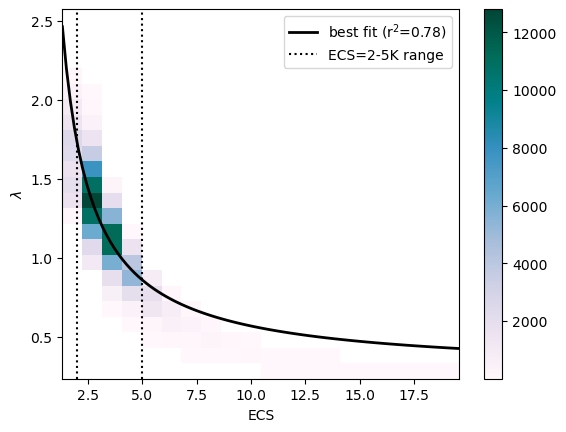

In [10]:
# fit check

counts, xedges, yedges = np.histogram2d(ecs_fair, lambda_fair, bins=20)
counts_nz = np.ma.masked_where(counts == 0, counts)
plt.pcolormesh(xedges, yedges, counts_nz.T, cmap="PuBuGn", vmin=1)
plt.colorbar()

xspan = np.linspace(ecs_fair.min(), ecs_fair.max(), 100)
plt.plot(xspan, calc_lambda_from_ecs(xspan), color="k", lw=2,
        label=f"best fit (r$^2$={r2:.2f})")

plt.ylabel("$\lambda$")
plt.xlabel("ECS")
plt.axvline(2, color="k", ls=":", label="ECS=2-5K range")
plt.axvline(5, color="k", ls=":")
plt.legend()

plt.show()


In [11]:
# then we can calculate lambda like this
calc_lambda_from_ecs(2), calc_lambda_from_ecs(5)


(1.7356570632260742, 0.8591183800993398)

#### Get the Sherwood ECS distribution from the CDF

In [12]:
# From the shared code/data for the Sherwood 2020 paper (via Zenodo)
df_ecs = pd.read_csv("/glade/work/jnug/WCRP_ECS_assessment_code_correction_2022/posteriors.txt.csv", index_col=0)

# this is the one we want
df_ecs.loc["ULI_MEDIUM_SAMPLE Posterior"]


P(ECS <1)       0.0000
P(ECS <1.5)     0.0011
P(ECS <2)       0.8925
P(ECS >4)      14.6081
P(ECS >4.5)     6.8588
P(ECS >6)       0.7720
P(1.5 -4.5)    93.1401
5th %ile        2.2550
10th %ile       2.4050
17th %ile       2.5550
20th %ile       2.6150
25th %ile       2.6950
50th %ile       3.1050
75th %ile       3.6250
80th %ile       3.7850
83rd %ile       3.8850
90th %ile       4.2350
95th %ile       4.6950
Mode            2.9550
Mean            3.2490
Name: ULI_MEDIUM_SAMPLE Posterior, dtype: float64

[1.5   2.    2.255 2.405 2.555 2.615 2.695 3.105 3.625 3.785 3.885 4.235
 4.695 6.   ]


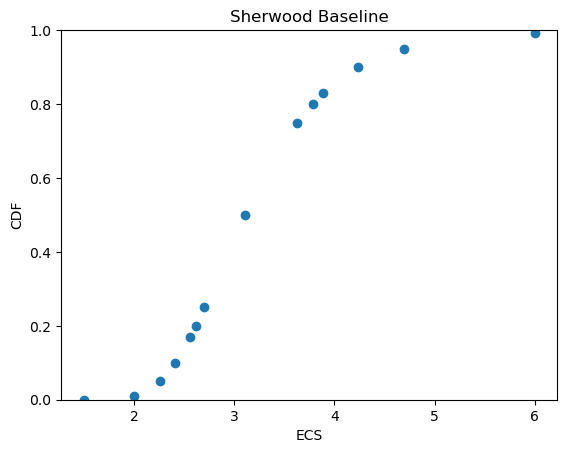

In [13]:
# get the CDF values from the data (i.e., hardcoded values copied from above)

y_cdf = np.array([p/100. for p in [0.0011, 0.8925, 5, 10, 17, 20, 25, 50, 75, 80, 83, 90, 95, (100-0.7720)]])
x_ecs = df_ecs.loc["ULI_MEDIUM_SAMPLE Posterior"].values[7:-2]
x_ecs = np.insert(x_ecs, 0, 2)
x_ecs = np.insert(x_ecs, 0, 1.5)
x_ecs = np.append(x_ecs, 6)
print(x_ecs)

plt.scatter(x_ecs, y_cdf)
plt.ylim(0, 1)
plt.ylabel("CDF")
plt.xlabel("ECS")
plt.title("Sherwood Baseline")
plt.show()


In [14]:
# invert the CDF to get the PDF and sample from that

inv_cdf = interp1d(y_cdf, x_ecs, bounds_error=False, fill_value=(x_ecs[0], x_ecs[1]))
n = 100000
u = np.random.uniform(0, 1, n)
samples = inv_cdf(u)


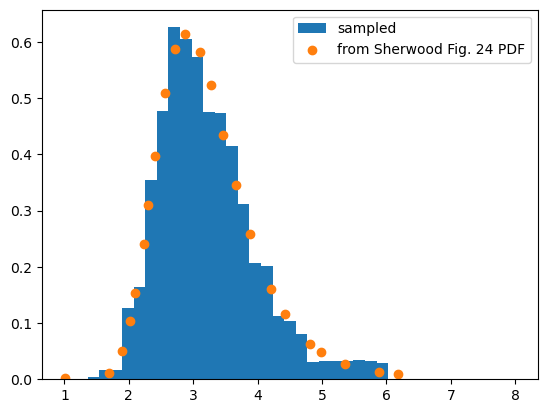

In [15]:
# compare to values pulled directly from Figure 24 to check this worked
x_ecs2 = [2.558252135468086, 3.886122676739494, 2.8756492252221317, 2.231068377902734, 2.406120959780229, 1.0128342705069322, 1.6961497188479204, 2.0937202214877453, 3.275099798257286, 3.6602051766321844, 4.425599862643258, 4.205811907112503, 4.989517963686311, 4.808541872344079, 3.4621024166201657, 3.1087264454650816, 2.7185216980727134, 2.2955573679014467, 2.025239301197579, 5.348508391638408, 5.878379190453707, 6.172700347684251, 1.8947160578615272]
y_pdf = [0.5085490780406035, 0.2574688023840566, 0.6138712981933321, 0.24034270813931832, 0.39721084000745016, 0.00249115291488175, 0.011682808716707044, 0.15255634196312162, 0.5229139504563234, 0.34490128515552243, 0.11544049171167817, 0.16043490407897187, 0.047853417768672024, 0.06342894393741855, 0.4335025144347178, 0.5822266716334512, 0.5870413484820265, 0.30990407897187555, 0.10302663438256661, 0.027630843732538685, 0.012269510150866109, 0.008618923449431964, 0.049818401937046036]

plt.hist(samples, bins=np.linspace(1, 8, 40), density=True, label="sampled")
plt.scatter(x_ecs2, y_pdf, color="C1", label="from Sherwood Fig. 24 PDF")
plt.legend()
plt.show()


#### Get lambda (climate feedback parameter for FaIR) from this distribution
Need 5000 random samples

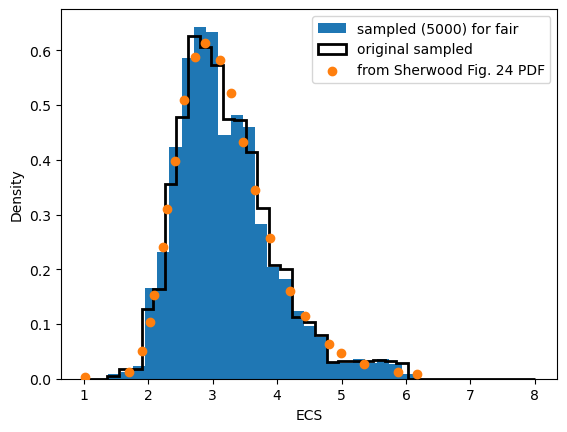

In [16]:
rng = np.random.default_rng(seed=20260604)

n_fair = 5000
u_fair = rng.uniform(low=0, high=1, size=n_fair) 
ecs_fair_sampled = inv_cdf(u_fair)

# check visually again that this worked 
plt.hist(ecs_fair_sampled, density=True, label="sampled (5000) for fair", bins=np.linspace(1, 6.5, 30))
plt.hist(samples, bins=np.linspace(1, 8, 40), density=True, histtype="step", color="k", lw=2, label="original sampled")
plt.scatter(x_ecs2, y_pdf, color="C1", label="from Sherwood Fig. 24 PDF", zorder=999)
plt.legend()
plt.ylabel("Density")
plt.xlabel("ECS")
plt.show()


In [17]:
# calculate lambda values corresponding to the ECS samples from Sherwood
lambda_sherwood = calc_lambda_from_ecs(ecs_fair_sampled)


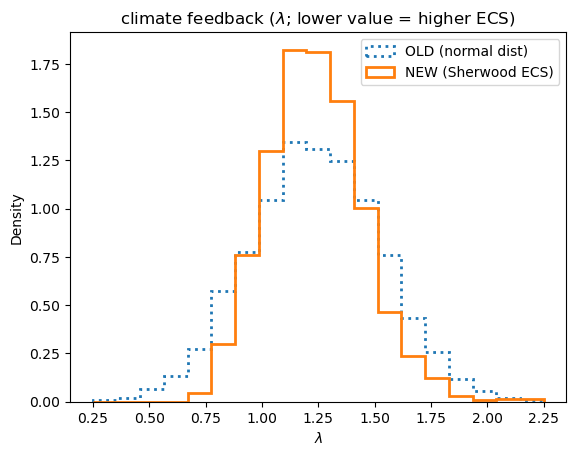

In [18]:
# compare to the old method (from first round of revisions)
# --> code here from fair_projections.py; this is what was used initially
lambda_old = fp.get_pdf90(lower=0.76, upper=1.72, rng=rng)

bins = np.linspace(0.25, 2.25, 20)
plt.hist(lambda_old, histtype="step", label=r"OLD (normal dist)", density=True, bins=bins, lw=2, ls=":")
plt.hist(lambda_sherwood, histtype="step", label=r"NEW (Sherwood ECS)", density=True, bins=bins, lw=2)
plt.title(r"climate feedback ($\lambda$; lower value = higher ECS)")
plt.legend(ncol=1)
plt.xlabel(r"$\lambda$")
plt.ylabel("Density")
plt.show()


#### Save the sampled lambda
Use this as input into the new fair calculations

In [57]:
pickle_path = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/"


In [59]:
np.savez(pickle_path + "lambda_5000_samples__from_Sherwood_ECS.npz", lambda_samples=lambda_sherwood)


### Clean plots for paper

In [19]:
fsize = 12
labsize = 11

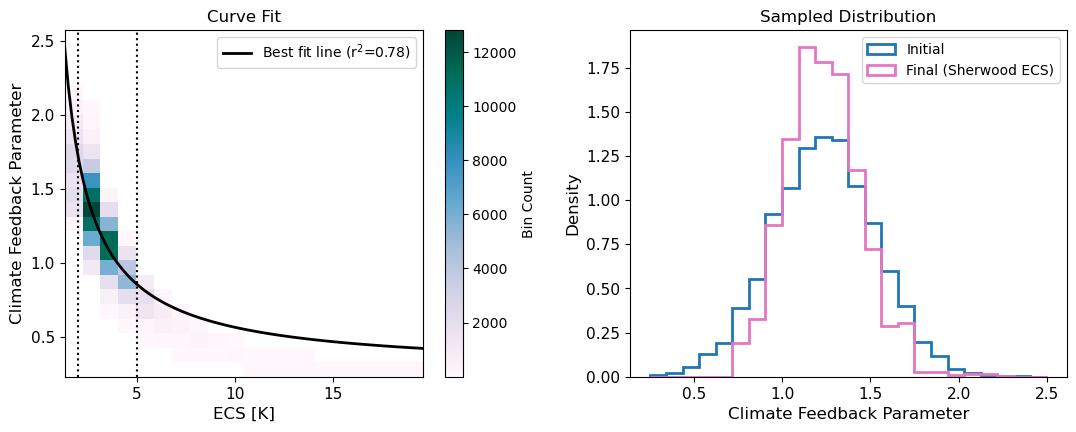

In [51]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(13, 4.5))
plt.subplots_adjust(wspace=0.25)

counts, xedges, yedges = np.histogram2d(ecs_fair, lambda_fair, bins=20)
counts_nz = np.ma.masked_where(counts == 0, counts)
pcm = ax1.pcolormesh(xedges, yedges, counts_nz.T, cmap="PuBuGn", vmin=1)
cbar = plt.colorbar(pcm, ax=ax1)
cbar.set_label("Bin Count")

xspan = np.linspace(ecs_fair.min(), ecs_fair.max(), 100)
ax1.plot(xspan, calc_lambda_from_ecs(xspan), color="k", lw=2,
        label=f"Best fit line (r$^2$={r2:.2f})")

ax1.set_ylabel("Climate Feedback Parameter", fontsize=fsize)
ax1.set_xlabel("ECS [K]", fontsize=fsize)
ax1.axvline(2, color="k", ls=":")
ax1.axvline(5, color="k", ls=":")
ax1.legend()


# compare to the old method (from first round of revisions)
# --> code here from fair_projections.py; this is what was used initially
lambda_old = fp.get_pdf90(lower=0.76, upper=1.72, rng=rng)

bins = np.linspace(0.25, 2.5, 25)
ax2.hist(lambda_old, histtype="step", label=r"Initial", density=True, lw=2, ls="-", bins=bins, color="C0")
ax2.hist(lambda_sherwood, histtype="step", label="Final (Sherwood ECS)", density=True, lw=2, bins=bins, color="C6")
ax2.legend(ncol=1)
ax2.set_xlabel("Climate Feedback Parameter", fontsize=fsize)
ax2.set_ylabel("Density", fontsize=fsize)
ax2.set_aspect(1)


for ax in [ax1, ax2]:
    ax.tick_params(axis="both", labelsize=labsize)

ax1.set_title("Curve Fit", fontsize=fsize)
ax2.set_title("Sampled Distribution", fontsize=fsize)

plt.savefig("./figures/lambda_to_ecs.png", dpi=300, bbox_inches="tight")
plt.show()
